In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import networkx as nx
from ase.build import molecule
from ase.data import covalent_radii, atomic_numbers as ase_atomic_numbers
from ase.neighborlist import NeighborList, natural_cutoffs

plt.rcParams.update({
    'font.family': 'sans-serif',
    'mathtext.fontset': 'dejavusans',
})


# %%
## Figure 1: Bond formation based on covalent radii

A bond is detected when the interatomic distance satisfies
$d \\leq \\beta\\,(r_A + r_B)$ where $\\beta$ is the neighbour-list multiplier
(`NL_MULT_DEFAULT = 0.90` in autokmc).

# %%

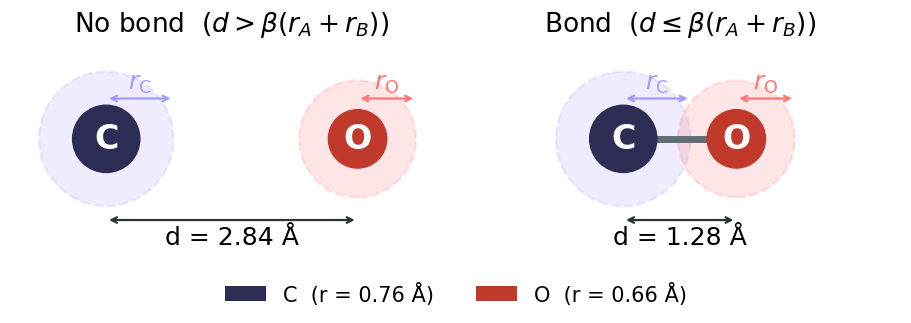

In [2]:
# ── element palette ───────────────────────────────────────────────────────────
ELEM_A, ELEM_B = 'C', 'O'
r_A = covalent_radii[ase_atomic_numbers[ELEM_A]]   # Å, C ≈ 0.77
r_B = covalent_radii[ase_atomic_numbers[ELEM_B]]   # Å, O ≈ 0.66

NL_MULT   = 0.90                          # autokmc NL_MULT_DEFAULT
d_thresh  = NL_MULT * (r_A + r_B)        # bond-detection cutoff

ATOM_CLR  = {'C': '#2C2C54', 'O': '#C0392B'}
SHELL_CLR = {'C': '#A29BFE', 'O': '#FF7675'}

SCALE = 3.5     # display units per Å

scenarios = [
    dict(d_Å=2.0 * (r_A + r_B), bonded=False,
         title=r'No bond  $(d > \beta(r_A+r_B))$'),
    dict(d_Å=d_thresh,            bonded=True,
         title=r'Bond  $(d \leq \beta(r_A+r_B))$'),
]

fig, axes = plt.subplots(1, 2, figsize=(9, 4.0), facecolor='white')

# Compute fixed plot limits based on the largest distance (no-bond case)
d_max_Å = 2.0 * (r_A + r_B)
d_max = d_max_Å * SCALE
lim_fixed = (d_max / 2 + max(r_A * SCALE, r_B * SCALE)) * 1.15

for ax, scen in zip(axes, scenarios):
    d      = scen['d_Å'] * SCALE
    x_A, x_B = -d / 2, d / 2
    rA_s, rB_s = r_A * SCALE, r_B * SCALE

    ax.set_aspect('equal')
    ax.axis('off')

    # covalent-radius shells (dashed)
    for xc, rs, elem in [(x_A, rA_s, ELEM_A), (x_B, rB_s, ELEM_B)]:
        ax.add_patch(mpatches.Circle(
            (xc, 0), rs,
            linestyle='--', linewidth=1.8,
            edgecolor=SHELL_CLR[elem],
            facecolor=SHELL_CLR[elem], alpha=0.18, zorder=2,
        ))

    # bond cylinder
    if scen['bonded']:
        ax.plot(
            [x_A + rA_s * 0.45, x_B - rB_s * 0.45], [0, 0],
            color='#636e72', lw=5, solid_capstyle='round', zorder=3,
        )

    # atom nuclei
    for xc, rs, elem in [(x_A, rA_s, ELEM_A), (x_B, rB_s, ELEM_B)]:
        ax.add_patch(mpatches.Circle(
            (xc, 0), rs * 0.50,
            color=ATOM_CLR[elem], zorder=5,
        ))
        ax.text(
            xc, 0, elem,
            ha='center', va='center',
            fontsize=24, fontweight='bold',
            color='white', zorder=6,
        )

    # covalent-radius bracket arrows
    y_r = max(rA_s, rB_s) * 0.60
    for xc, rs, elem, lbl in [
        (x_A, rA_s, ELEM_A, r'$r_\mathrm{C}$'),
        (x_B, rB_s, ELEM_B, r'$r_\mathrm{O}$'),
    ]:
        ax.annotate(
            '', xy=(xc + rs, y_r), xytext=(xc, y_r),
            arrowprops=dict(arrowstyle='<->', color=SHELL_CLR[elem], lw=1.6),
        )
        ax.text(
            xc + rs / 2, y_r + 0.15, lbl,
            ha='center', va='bottom', fontsize=18, color=SHELL_CLR[elem],
        )

    # inter-atomic distance arrow
    y_d = -(max(rA_s, rB_s) + 0.55)
    ax.annotate(
        '', xy=(x_B, y_d), xytext=(x_A, y_d),
        arrowprops=dict(arrowstyle='<->', color='#2d3436', lw=1.6),
    )
    ax.text(
        0, y_d - 0.20,
        f'd = {scen["d_Å"]:.2f} Å',
        ha='center', va='top', fontsize=18,
    )

    ax.set_title(scen['title'], fontsize=19, pad=-0.8)
    ax.set_xlim(-lim_fixed, lim_fixed)
    ax.set_ylim(-lim_fixed * 0.60, lim_fixed * 0.45)

# footer

legend_patches = [
    mpatches.Patch(facecolor='#2C2C54', label=f'C  (r = {r_A:.2f} Å)'),
    mpatches.Patch(facecolor='#C0392B', label=f'O  (r = {r_B:.2f} Å)'),
]
fig.legend(
    handles=legend_patches, loc='lower center',
    ncol=2, fontsize=15, frameon=False,
    bbox_to_anchor=(0.5, 0.10),
)

plt.tight_layout(pad=0.3)
fig.subplots_adjust(bottom=0.05)
plt.savefig('bond_formation.pdf', bbox_inches='tight')
plt.show()

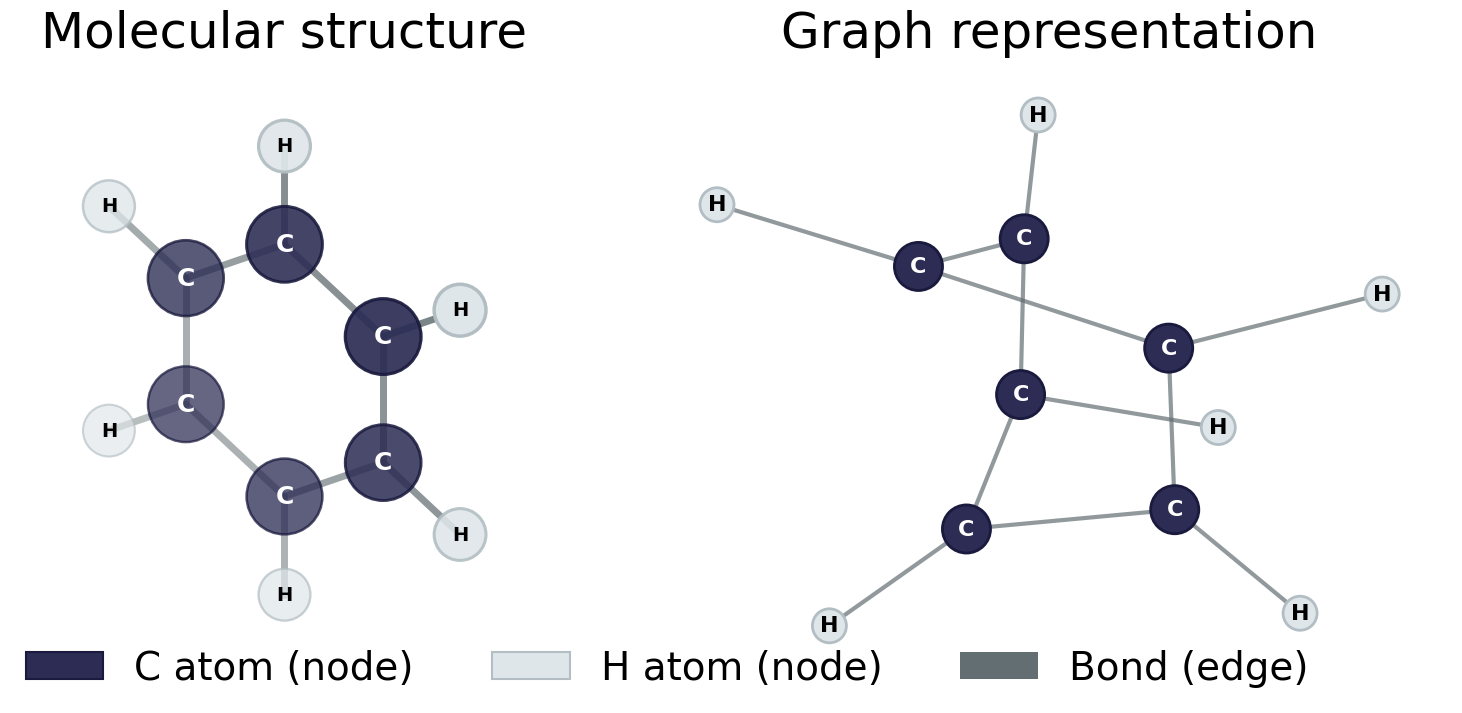

Benzene: 12 atoms, 12 bonds  (BOND_MULT=1.1)


In [3]:
# %%
## Figure 2: Ethane — molecular render and graph representation

# %%
# ── build ethane ──────────────────────────────────────────────────────────────
eth       = molecule('C6H6')
positions = eth.get_positions()
symbols   = eth.get_chemical_symbols()
numbers   = eth.get_atomic_numbers()
n_atoms   = len(eth)

# detect bonds (mult=1.1 comfortably covers C-C 1.54 Å and C-H 1.09 Å)
BOND_MULT = 1.1
nl = NeighborList(
    natural_cutoffs(eth, mult=BOND_MULT),
    self_interaction=False, bothways=False,
)
nl.update(eth)
bond_pairs = [
    (i, int(j))
    for i in range(n_atoms)
    for j in nl.get_neighbors(i)[0]
    if int(j) > i
]

# 3-D rotation for a nice isometric view
tx, ty = np.radians(25), np.radians(-35)
Rx = np.array([[1, 0, 0],
               [0, np.cos(tx), -np.sin(tx)],
               [0, np.sin(tx),  np.cos(tx)]])
Ry = np.array([[ np.cos(ty), 0, np.sin(ty)],
               [0,           1, 0          ],
               [-np.sin(ty), 0, np.cos(ty)]])
pos_rot = positions @ Ry.T @ Rx.T
x2d, y2d, z2d = pos_rot[:, 0], pos_rot[:, 1], pos_rot[:, 2]

# palette
CPK_COLOR  = {'C': '#2C2C54', 'H': '#DFE6E9'}
CPK_EDGE   = {'C': '#1a1a3e', 'H': '#b2bec3'}
ATOM_SCAT  = {'C': 1200,      'H': 600}     # node sizes for graph panel
RENDER_R   = {'C': 0.38,      'H': 0.26}    # display radii for render panel

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 7), facecolor='white',
)

# ─────────────────────────────────────────────────────────────────────────────
# Panel A: ball-and-stick molecular render
# ─────────────────────────────────────────────────────────────────────────────
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title(r'Molecular structure',
              fontsize=36, pad=10)

# draw bonds first (depth-tinted)
z_min, z_max = z2d.min(), z2d.max()
for i, j in bond_pairs:
    z_avg  = (z2d[i] + z2d[j]) / 2
    alpha  = 0.40 + 0.50 * (z_avg - z_min) / (z_max - z_min + 1e-9)
    ax1.plot(
        [x2d[i], x2d[j]], [y2d[i], y2d[j]],
        color='#636e72', lw=5,
        solid_capstyle='round', alpha=float(alpha), zorder=1,
    )

# draw atoms back-to-front
for idx in np.argsort(z2d):          # ascending z → back first
    elem    = symbols[idx]
    depth_f = (z2d[idx] - z_min) / (z_max - z_min + 1e-9)
    r_disp  = RENDER_R[elem]
    ax1.add_patch(mpatches.Circle(
        (x2d[idx], y2d[idx]), r_disp,
        facecolor=CPK_COLOR[elem],
        edgecolor=CPK_EDGE[elem],
        linewidth=1.5 + depth_f,
        alpha=0.65 + 0.35 * depth_f,
        zorder=3 + int(depth_f * 6),
    ))
    ax1.text(
        x2d[idx], y2d[idx], elem,
        ha='center', va='center',
        fontsize=14 if elem == 'H' else 18,
        fontweight='bold',
        color='black' if elem == 'H' else 'white',
        zorder=20,
    )

pad = 0.85
ax1.set_xlim(x2d.min() - pad, x2d.max() + pad)
ax1.set_ylim(y2d.min() - pad, y2d.max() + pad)

# ─────────────────────────────────────────────────────────────────────────────
# Panel B: graph representation
# ─────────────────────────────────────────────────────────────────────────────
ax2.set_title(r'Graph representation',
              fontsize=36, pad=10)
ax2.axis('off')

# build nx.Graph using the same bond list
G = nx.Graph()
for idx in range(n_atoms):
    G.add_node(idx, element=symbols[idx])
for i, j in bond_pairs:
    d_ij = float(np.linalg.norm(positions[i] - positions[j]))
    G.add_edge(i, j, distance=round(d_ij, 3))

# use spring layout for a clean graph topology (not atomic positions)
graph_pos = nx.spring_layout(G, seed=69)

node_colors = [CPK_COLOR[symbols[i]] for i in G.nodes()]
node_edges  = [CPK_EDGE[symbols[i]]  for i in G.nodes()]
node_sizes  = [ATOM_SCAT[symbols[i]] for i in G.nodes()]

nx.draw_networkx_edges(
    G, graph_pos, ax=ax2,
    edge_color='#636e72', width=3.0, alpha=0.70,
)
nx.draw_networkx_nodes(
    G, graph_pos, ax=ax2,
    node_color=node_colors,
    edgecolors=node_edges,
    node_size=node_sizes,
    linewidths=2.0,
)
# draw node labels manually for per-node colour control
for node, (x, y) in graph_pos.items():
    elem  = symbols[node]
    color = 'black' if elem == 'H' else 'white'
    ax2.text(x, y, elem, ha='center', va='center',
             fontsize=16, fontweight='bold', color=color, zorder=6)

# ── shared legend ─────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor=CPK_COLOR['C'], edgecolor=CPK_EDGE['C'],
                   linewidth=1.5, label='C atom (node)'),
    mpatches.Patch(facecolor=CPK_COLOR['H'], edgecolor=CPK_EDGE['H'],
                   linewidth=1.5, label='H atom (node)'),
    mpatches.Patch(facecolor='#636e72', label='Bond (edge)'),
]
fig.legend(
    handles=legend_patches, loc='lower center',
    ncol=3, fontsize=28, frameon=False,
    bbox_to_anchor=(0.5, -0.04),
)

plt.tight_layout()
plt.savefig('molecular_graph.pdf', bbox_inches='tight')
plt.show()
print(f'Benzene: {n_atoms} atoms, {G.number_of_edges()} bonds  (BOND_MULT={BOND_MULT})')


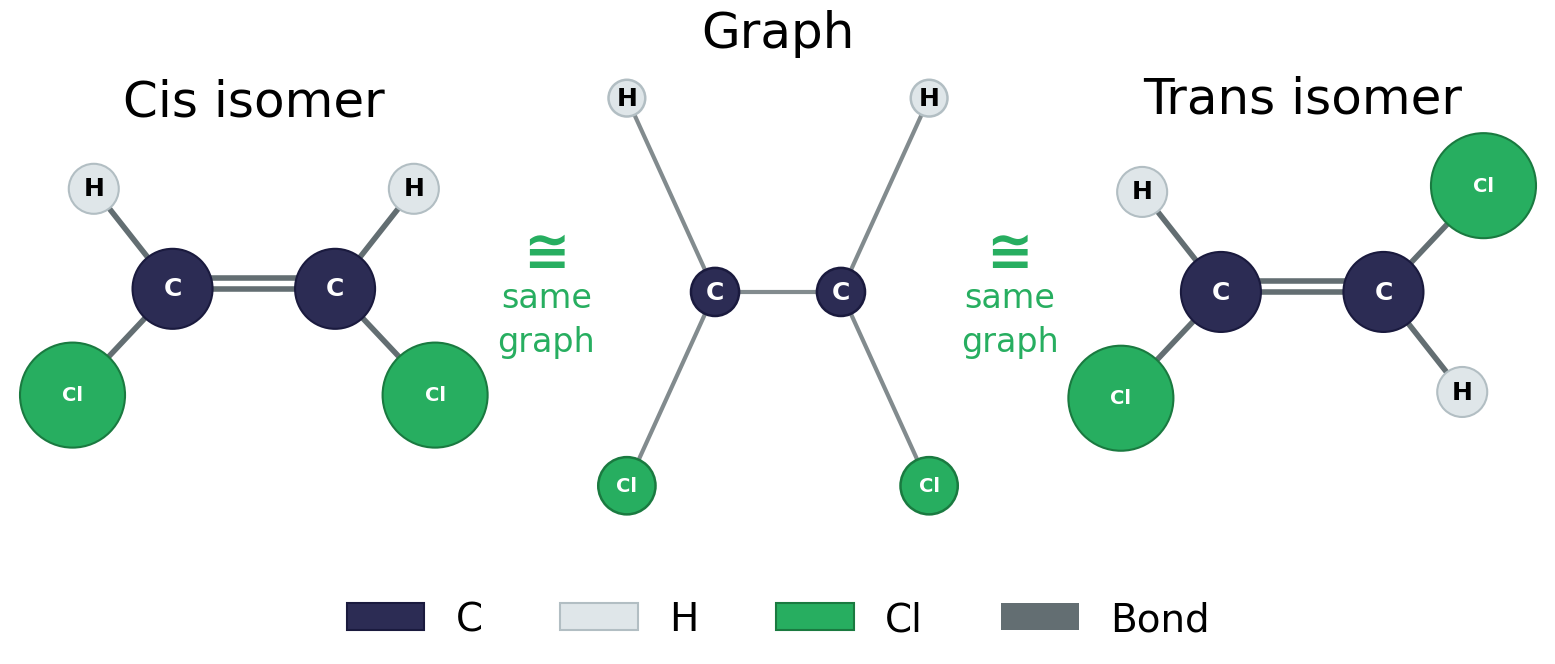

In [4]:
# ── Figure 3: Stereoisomers — same graph, different chemistry ─────────────────
from matplotlib.gridspec import GridSpec as GS4

SCLR  = {'C': '#2C2C54', 'H': '#DFE6E9', 'Cl': '#27ae60'}
SEDGE = {'C': '#1a1a3e', 'H': '#b2bec3',  'Cl': '#1a7a40'}
SRAD  = {'C': 0.32,      'H': 0.20,       'Cl': 0.42}
SNS   = {'C': 1200,      'H': 700,        'Cl': 1700}

def draw_mol(ax, atoms, bonds, title):
    """Ball-and-stick 2-D diagram with double-bond indicator for C=C."""
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=36, pad=6)
    for a, b in bonds:
        x0, y0 = atoms[a]['pos']
        x1, y1 = atoms[b]['pos']
        ax.plot([x0,x1],[y0,y1], color='#636e72', lw=4,
                solid_capstyle='round', zorder=1)
        if atoms[a]['elem'] == 'C' and atoms[b]['elem'] == 'C':
            dx, dy = x1-x0, y1-y0
            n = np.sqrt(dx**2+dy**2)
            ox, oy = -dy/n*0.09, dx/n*0.09
            ax.plot([x0+ox,x1+ox],[y0+oy,y1+oy], color='#636e72',
                    lw=4, solid_capstyle='round', zorder=1)
    for info in atoms.values():
        x, y = info['pos']; e = info['elem']
        ax.add_patch(mpatches.Circle((x,y), SRAD[e],
            facecolor=SCLR[e], edgecolor=SEDGE[e], linewidth=1.5, zorder=3))
        fc = 'black' if e == 'H' else 'white'
        fs = 14 if e == 'Cl' else 18
        ax.text(x, y, e, ha='center', va='center',
                fontsize=fs, fontweight='bold', color=fc, zorder=4)
    xs = [v['pos'][0] for v in atoms.values()]
    ys = [v['pos'][1] for v in atoms.values()]
    ax.set_xlim(min(xs)-.5, max(xs)+.5)
    ax.set_ylim(min(ys)-.5, max(ys)+.5)

# ── cis: both Cl on the same side of C=C ─────────────────────────────────────
cis = {
    'C1':  {'pos': (-0.65,  0.00), 'elem': 'C'},
    'C2':  {'pos': ( 0.65,  0.00), 'elem': 'C'},
    'H1':  {'pos': (-1.28,  0.80), 'elem': 'H'},
    'Cl1': {'pos': (-1.45, -0.85), 'elem': 'Cl'},
    'H2':  {'pos': ( 1.28,  0.80), 'elem': 'H'},
    'Cl2': {'pos': ( 1.45, -0.85), 'elem': 'Cl'},   # same side as Cl1
}
bonds_cis = [('C1','C2'),('C1','H1'),('C1','Cl1'),('C2','H2'),('C2','Cl2')]

# ── trans: Cl on opposite sides of C=C ───────────────────────────────────────
trans = {
    'C1':  {'pos': (-0.65,  0.00), 'elem': 'C'},
    'C2':  {'pos': ( 0.65,  0.00), 'elem': 'C'},
    'H1':  {'pos': (-1.28,  0.80), 'elem': 'H'},
    'Cl1': {'pos': (-1.45, -0.85), 'elem': 'Cl'},
    'H2':  {'pos': ( 1.28, -0.80), 'elem': 'H'},
    'Cl2': {'pos': ( 1.45,  0.85), 'elem': 'Cl'},   # opposite side to Cl1
}
bonds_trans = [('C1','C2'),('C1','H1'),('C1','Cl1'),('C2','H2'),('C2','Cl2')]

# ── the shared graph (identical for both isomers) ─────────────────────────────
elems4 = {0:'C', 1:'C', 2:'H', 3:'Cl', 4:'H', 5:'Cl'}
G4 = nx.Graph()
for n, e in elems4.items(): G4.add_node(n, element=e)
G4.add_edges_from([(0,1),(0,2),(0,3),(1,4),(1,5)])
gpos4 = {0:(-0.5, 0.0), 1:(0.5, 0.0),
         2:(-1.2, 0.8),  3:(-1.2,-0.8),
         4:( 1.2, 0.8),  5:( 1.2,-0.8)}

# ── figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 7), facecolor='white')
gs4 = GS4(1, 5, figure=fig,
           width_ratios=[4, 0.8, 3, 0.8, 4], wspace=0.0,
           left=0.02, right=0.98, top=0.85, bottom=0.18)

ax_cis   = fig.add_subplot(gs4[0])
ax_s1    = fig.add_subplot(gs4[1])
ax_graph = fig.add_subplot(gs4[2])
ax_s2    = fig.add_subplot(gs4[3])
ax_trans = fig.add_subplot(gs4[4])

draw_mol(ax_cis,   cis,   bonds_cis,   'Cis isomer')
draw_mol(ax_trans, trans, bonds_trans, 'Trans isomer')

ax_graph.set_title('Graph', fontsize=36, pad=4)
ax_graph.axis('off')
nx.draw_networkx_edges(G4, gpos4, ax=ax_graph,
                       edge_color='#636e72', width=3.0, alpha=0.80)
nx.draw_networkx_nodes(G4, gpos4, ax=ax_graph,
                       node_color=[SCLR[elems4[n]]  for n in G4.nodes()],
                       edgecolors=[SEDGE[elems4[n]] for n in G4.nodes()],
                       node_size=[SNS[elems4[n]] for n in G4.nodes()],
                       linewidths=1.8)
for node, (x, y) in gpos4.items():
    e  = elems4[node]
    fc = 'black' if e == 'H' else 'white'
    fs = 14 if e == 'Cl' else 18
    ax_graph.text(x, y, e, ha='center', va='center',
                  fontsize=fs, fontweight='bold', color=fc, zorder=5)

for ax_s in (ax_s1, ax_s2):
    ax_s.axis('off')
    ax_s.text(0.5, 0.58, '≅', ha='center', va='center',
              transform=ax_s.transAxes, fontsize=40,
              color='#27ae60', fontweight='bold')
    ax_s.text(0.5, 0.44, 'same\ngraph', ha='center', va='center',
              transform=ax_s.transAxes, fontsize=24,
              color='#27ae60', linespacing=1.4)

# fig.text(0.5, 0.97,
#          'Cis/trans stereoisomers: same connectivity graph, different spatial arrangement',
#          ha='center', va='top', fontsize=11, style='italic', color='#555555')

lp4 = [
    mpatches.Patch(facecolor=SCLR['C'],  edgecolor=SEDGE['C'],  linewidth=1.5, label='C'),
    mpatches.Patch(facecolor=SCLR['H'],  edgecolor=SEDGE['H'],  linewidth=1.5, label='H'),
    mpatches.Patch(facecolor=SCLR['Cl'], edgecolor=SEDGE['Cl'], linewidth=1.5, label='Cl'),
    mpatches.Patch(facecolor='#636e72', label='Bond'),
]
fig.legend(handles=lp4, loc='lower center', ncol=4,
           fontsize=28, frameon=False, bbox_to_anchor=(0.5, -0.03))

plt.savefig('stereoisomers.pdf', bbox_inches='tight')
plt.show()


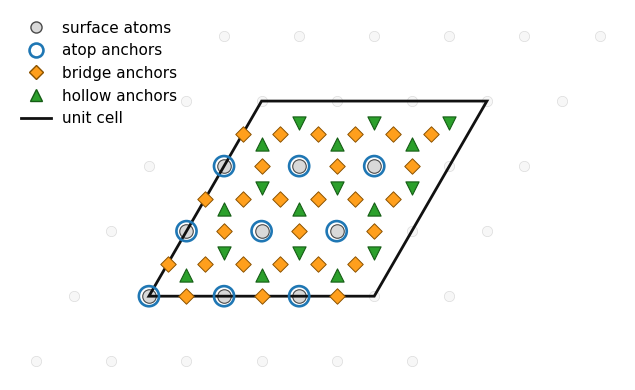

In [5]:
# -- Figure 4: Top-down surface unit cell with anchor sites -------------------
# This mirrors the get_anchors.py visual intent, but uses a clean 2-D top-down
# projection for the memo: only surface atoms, the unit-cell boundary, and the
# anchor-site positions are shown.

# A compact triangular surface lattice shown as a 3 x 3 periodic unit cell.
a1 = np.array([1.0, 0.0])
a2 = np.array([0.5, np.sqrt(3.0) / 2.0])
nx_cell, ny_cell = 3, 3
cell_mat = np.column_stack([nx_cell * a1, ny_cell * a2])
cell_inv = np.linalg.inv(cell_mat)


def site_pos(i, j):
    return i * a1 + j * a2


def frac_in_cell(point):
    return cell_inv @ np.asarray(point, dtype=float)


def in_unit_cell(point, eps=1e-8):
    u, v = frac_in_cell(point)
    return -eps <= u < 1.0 - eps and -eps <= v < 1.0 - eps


# Surface atoms visible around the cell, with in-cell atoms used for atop sites.
surface_atoms = []
for i in range(-1, nx_cell + 2):
    for j in range(-1, ny_cell + 2):
        p = site_pos(i, j)
        surface_atoms.append((i, j, p, in_unit_cell(p)))

# Anchor positions generated across the full cell.
top_sites = [p for _i, _j, p, is_inside in surface_atoms if is_inside]

neighbor_offsets = [(1, 0), (0, 1), (1, -1)]
bridge_sites = []
seen_bridge = set()
for i in range(-1, nx_cell + 1):
    for j in range(-1, ny_cell + 1):
        p = site_pos(i, j)
        for di, dj in neighbor_offsets:
            m = 0.5 * (p + site_pos(i + di, j + dj))
            if in_unit_cell(m):
                key = tuple(np.round(m, 8))
                if key not in seen_bridge:
                    seen_bridge.add(key)
                    bridge_sites.append(m)

hollow_up = []
hollow_down = []
for i in range(-1, nx_cell + 1):
    for j in range(-1, ny_cell + 1):
        p = site_pos(i, j)
        h_up = p + (a1 + a2) / 3.0
        h_down = p + 2.0 * (a1 + a2) / 3.0
        if in_unit_cell(h_up):
            hollow_up.append(h_up)
        if in_unit_cell(h_down):
            hollow_down.append(h_down)

fig, ax = plt.subplots(figsize=(6.2, 5.2), facecolor='white')
ax.set_aspect('equal')
ax.axis('off')

# Unit-cell boundary.
cell_poly = np.array([
    site_pos(0, 0),
    site_pos(nx_cell, 0),
    site_pos(nx_cell, ny_cell),
    site_pos(0, ny_cell),
])
ax.add_patch(mpatches.Polygon(
    cell_poly, closed=True, fill=False,
    edgecolor='#111111', linewidth=2.0, zorder=7,
))

# Surface atoms only; no surface bonds, to keep the figure top-down and clean.
all_xy = np.vstack([p for _i, _j, p, _inside in surface_atoms])
in_xy = np.vstack([p for _i, _j, p, inside in surface_atoms if inside])
out_xy = np.vstack([p for _i, _j, p, inside in surface_atoms if not inside])
ax.scatter(
    out_xy[:, 0], out_xy[:, 1],
    s=55, facecolor='#eeeeee', edgecolor='#b6b6b6', linewidth=0.5,
    alpha=0.45, zorder=1,
)
ax.scatter(
    in_xy[:, 0], in_xy[:, 1],
    s=95, facecolor='#d9d9d9', edgecolor='#4a4a4a', linewidth=0.8,
    zorder=2, label='surface atoms',
)

# Anchor markers.
def scatter_sites(points, **kwargs):
    arr = np.asarray(points, dtype=float)
    if arr.size:
        ax.scatter(arr[:, 0], arr[:, 1], **kwargs)

scatter_sites(
    top_sites,
    s=210, facecolor='none', edgecolor='#1f77b4', linewidth=1.9,
    zorder=8, label='atop anchors',
)
scatter_sites(
    bridge_sites,
    s=62, marker='D', facecolor='#ff9f1c', edgecolor='#8a5200', linewidth=0.7,
    zorder=9, label='bridge anchors',
)
scatter_sites(
    hollow_up,
    s=90, marker='^', facecolor='#2ca02c', edgecolor='#155d15', linewidth=0.8,
    zorder=9, label='hollow anchors',
)
scatter_sites(
    hollow_down,
    s=90, marker='v', facecolor='#2ca02c', edgecolor='#155d15', linewidth=0.8,
    zorder=9,
)

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='none', markersize=8,
           markerfacecolor='#d9d9d9', markeredgecolor='#4a4a4a',
           label='surface atoms'),
    Line2D([0], [0], marker='o', linestyle='none', markersize=10,
           markerfacecolor='none', markeredgecolor='#1f77b4',
           markeredgewidth=1.9, label='atop anchors'),
    Line2D([0], [0], marker='D', linestyle='none', markersize=7,
           markerfacecolor='#ff9f1c', markeredgecolor='#8a5200',
           label='bridge anchors'),
    Line2D([0], [0], marker='^', linestyle='none', markersize=8,
           markerfacecolor='#2ca02c', markeredgecolor='#155d15',
           label='hollow anchors'),
    Line2D([0], [0], color='#111111', linewidth=2.0, label='unit cell'),
]
ax.legend(handles=legend_handles, loc='upper left', frameon=False,
          fontsize=11, handletextpad=0.7, borderaxespad=0.3)

ax.set_xlim(all_xy[:, 0].min() - 0.35, all_xy[:, 0].max() + 0.35)
ax.set_ylim(all_xy[:, 1].min() - 0.25, all_xy[:, 1].max() + 0.35)

plt.tight_layout(pad=0.15)
plt.savefig('anchor_site_selection.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# -- Figure 5: CO adsorbate binding-clique enumeration -----------------------
from matplotlib.gridspec import GridSpec as GS5

fig = plt.figure(figsize=(12.8, 6.25), facecolor='white')
gs = GS5(1, 3, figure=fig, width_ratios=[0.72, 1.55, 1.34], wspace=0.28)

C_COLOR = '#1f77b4'
O_COLOR = '#d62728'
SURF_COLOR = '#d9d9d9'
ACCEPT_COLOR = '#2ca02c'
REJECT_COLOR = '#b9b9b9'
BAND_COLOR = '#7fc97f'
EDGE_COLOR = '#202020'
ATOM_FS = 28
LABEL_FS = 24
SMALL_LABEL_FS = 18
LEGEND_FS = 16


def clean_axis(ax):
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def draw_surface(ax, atoms, alpha=1.0):
    ax.scatter(
        atoms[:, 0], atoms[:, 1], s=118,
        facecolor=SURF_COLOR, edgecolor='#6b6b6b', linewidth=0.9,
        alpha=alpha, zorder=1,
    )

# Surface atoms and horizontal bridge-anchor cliques for a compact schematic.
a = 1.0
dy = np.sqrt(3) / 2
surface_rows = []
for j in range(4):
    row = []
    for i in range(5):
        row.append(np.array([i + 0.5 * (j % 2), j * dy], dtype=float))
    surface_rows.append(row)
surface_atoms = np.vstack(surface_rows)

bridge_sites = []
bridge_cliques = []
for row in surface_rows:
    for left, right in zip(row[:-1], row[1:]):
        bridge_sites.append((left + right) / 2)
        bridge_cliques.append((left, right))
bridge_sites = np.asarray(bridge_sites)

c_anchor = (surface_rows[1][1] + surface_rows[1][2]) / 2
c_clique = (surface_rows[1][1], surface_rows[1][2])
d_co = 1.0
tau = 0.09
candidate_dist = np.linalg.norm(bridge_sites - c_anchor, axis=1)
accepted = (np.abs(candidate_dist - d_co) <= tau) & (candidate_dist > 1e-6)
rejected = ~accepted & (candidate_dist > 1e-6)
r_site = bridge_sites[accepted][np.argmax(bridge_sites[accepted][:, 0])]

# Pick one accepted O anchor for the candidate site panel.
o_anchor = (surface_rows[0][2] + surface_rows[0][3]) / 2
o_clique = (surface_rows[0][2], surface_rows[0][3])

# Panel 1: molecular distance from the gas-phase C-O graph.
ax0 = fig.add_subplot(gs[0, 0])
clean_axis(ax0)
c_xy = np.array([0.0, 0.88])
o_xy = np.array([0.0, -0.88])
ax0.plot([c_xy[0], o_xy[0]], [c_xy[1], o_xy[1]], color=EDGE_COLOR, linewidth=3.2, zorder=1)
ax0.scatter([c_xy[0]], [c_xy[1]], s=900, facecolor=C_COLOR, edgecolor=EDGE_COLOR, linewidth=1.4, zorder=3)
ax0.scatter([o_xy[0]], [o_xy[1]], s=900, facecolor=O_COLOR, edgecolor=EDGE_COLOR, linewidth=1.4, zorder=3)
ax0.text(c_xy[0], c_xy[1], 'C', color='white', ha='center', va='center', fontsize=ATOM_FS, fontweight='bold')
ax0.text(o_xy[0], o_xy[1], 'O', color='white', ha='center', va='center', fontsize=ATOM_FS, fontweight='bold')
ax0.annotate('', xy=(0.54, o_xy[1] + 0.08), xytext=(0.54, c_xy[1] - 0.08),
             arrowprops=dict(arrowstyle='<->', linewidth=2.4, color=EDGE_COLOR))
ax0.text(0.72, 0.0, 'C-O\ndistance\n= r',
         ha='left', va='center', fontsize=LABEL_FS, color=EDGE_COLOR,
         linespacing=0.86)
ax0.set_xlim(-0.72, 2.18)
ax0.set_ylim(-1.48, 1.48)

# Panel 2: use the molecular distance as a filter on surface anchor pairs.
ax1 = fig.add_subplot(gs[0, 1])
clean_axis(ax1)
draw_surface(ax1, surface_atoms, alpha=0.95)

window = mpatches.Wedge(
    c_anchor, d_co + tau, 0, 360, width=2 * tau,
    facecolor=BAND_COLOR, edgecolor='none', alpha=0.20, zorder=2,
)
ax1.add_patch(window)
ax1.add_patch(mpatches.Circle(c_anchor, d_co, fill=False, linestyle='--',
                              edgecolor=ACCEPT_COLOR, linewidth=2.2, zorder=3))
ax1.scatter(bridge_sites[rejected, 0], bridge_sites[rejected, 1], s=72, marker='x',
            color=REJECT_COLOR, linewidth=1.8, zorder=4)
ax1.scatter(bridge_sites[accepted, 0], bridge_sites[accepted, 1], s=145, marker='s',
            facecolor='#fdae6b', edgecolor=ACCEPT_COLOR, linewidth=2.0, zorder=5)
ax1.scatter([c_anchor[0]], [c_anchor[1]], s=260, marker='o',
            facecolor=C_COLOR, edgecolor=EDGE_COLOR, linewidth=1.2, zorder=6)
ax1.text(c_anchor[0], c_anchor[1], 'C', color='white', ha='center', va='center',
         fontsize=SMALL_LABEL_FS, fontweight='bold', zorder=7)
ax1.annotate('', xy=(r_site[0] - 0.08, r_site[1] + 0.25),
             xytext=(c_anchor[0] + 0.14, c_anchor[1] + 0.25),
             arrowprops=dict(arrowstyle='<->', linewidth=2.4, color=EDGE_COLOR),
             zorder=8)
ax1.text(0.5 * (c_anchor[0] + r_site[0]), c_anchor[1] + 0.42, 'r',
         ha='center', va='bottom', fontsize=LABEL_FS + 7,
         fontweight='bold', color=EDGE_COLOR, zorder=9)
ax1.set_xlim(-0.35, 4.85)
ax1.set_ylim(-0.55, 3.25)
ax1.legend(
    handles=[
        Line2D([0], [0], marker='o', linestyle='none', markersize=9,
               markerfacecolor=SURF_COLOR, markeredgecolor='#6b6b6b', label='surface atoms'),
        Line2D([0], [0], marker='o', linestyle='none', markersize=11,
               markerfacecolor=C_COLOR, markeredgecolor=EDGE_COLOR, label='chosen C anchor'),
        Line2D([0], [0], marker='s', linestyle='none', markersize=9,
               markerfacecolor='#fdae6b', markeredgecolor=ACCEPT_COLOR, label='accepted O anchors'),
        Line2D([0], [0], marker='x', linestyle='none', markersize=9,
               color=REJECT_COLOR, label='rejected O anchors'),
    ],
    loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2,
    frameon=False, fontsize=LEGEND_FS, handletextpad=0.45, columnspacing=0.95,
)

# Panel 3: accepted pair becomes a candidate binding-clique union.
ax2 = fig.add_subplot(gs[0, 2])
clean_axis(ax2)
draw_surface(ax2, surface_atoms, alpha=0.92)


def draw_clique(ax, clique, color):
    pts = np.vstack(clique)
    ax.plot(pts[:, 0], pts[:, 1], color=color, linewidth=6.2, alpha=0.28,
            solid_capstyle='round', zorder=2)
    ax.scatter(pts[:, 0], pts[:, 1], s=220, facecolor='white', edgecolor=color,
               linewidth=2.7, zorder=4)


def dashed_bonds(ax, atom_xy, clique, color):
    for surf_xy in clique:
        ax.plot([atom_xy[0], surf_xy[0]], [atom_xy[1], surf_xy[1]],
                color=color, linestyle=':', linewidth=2.0, zorder=3)


draw_clique(ax2, c_clique, C_COLOR)
draw_clique(ax2, o_clique, O_COLOR)
dashed_bonds(ax2, c_anchor, c_clique, C_COLOR)
dashed_bonds(ax2, o_anchor, o_clique, O_COLOR)
ax2.plot([c_anchor[0], o_anchor[0]], [c_anchor[1], o_anchor[1]],
         color=EDGE_COLOR, linewidth=2.7, zorder=5)
ax2.scatter([c_anchor[0]], [c_anchor[1]], s=330, facecolor=C_COLOR,
            edgecolor=EDGE_COLOR, linewidth=1.3, zorder=6)
ax2.scatter([o_anchor[0]], [o_anchor[1]], s=330, facecolor=O_COLOR,
            edgecolor=EDGE_COLOR, linewidth=1.3, zorder=6)
ax2.text(c_anchor[0], c_anchor[1], 'C', color='white', ha='center', va='center',
         fontsize=SMALL_LABEL_FS, fontweight='bold', zorder=7)
ax2.text(o_anchor[0], o_anchor[1], 'O', color='white', ha='center', va='center',
         fontsize=SMALL_LABEL_FS, fontweight='bold', zorder=7)
ax2.text(0.04, 0.88, 'candidate CO site:\nC clique + O clique',
         transform=ax2.transAxes, ha='left', va='top', fontsize=LABEL_FS,
         color=EDGE_COLOR,
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.90, pad=2.2))
ax2.set_xlim(0.95, 4.10)
ax2.set_ylim(-0.55, 2.65)
ax2.legend(
    handles=[
        Line2D([0], [0], color=C_COLOR, linewidth=5, alpha=0.50, label='C surface clique'),
        Line2D([0], [0], color=O_COLOR, linewidth=5, alpha=0.50, label='O surface clique'),
        Line2D([0], [0], color=EDGE_COLOR, linewidth=2.5, label='C-O bond'),
    ],
    loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=1,
    frameon=False, fontsize=LEGEND_FS, handlelength=1.6,
)

plt.savefig('adsorbate_binding_cliques.pdf', bbox_inches='tight')
plt.show()


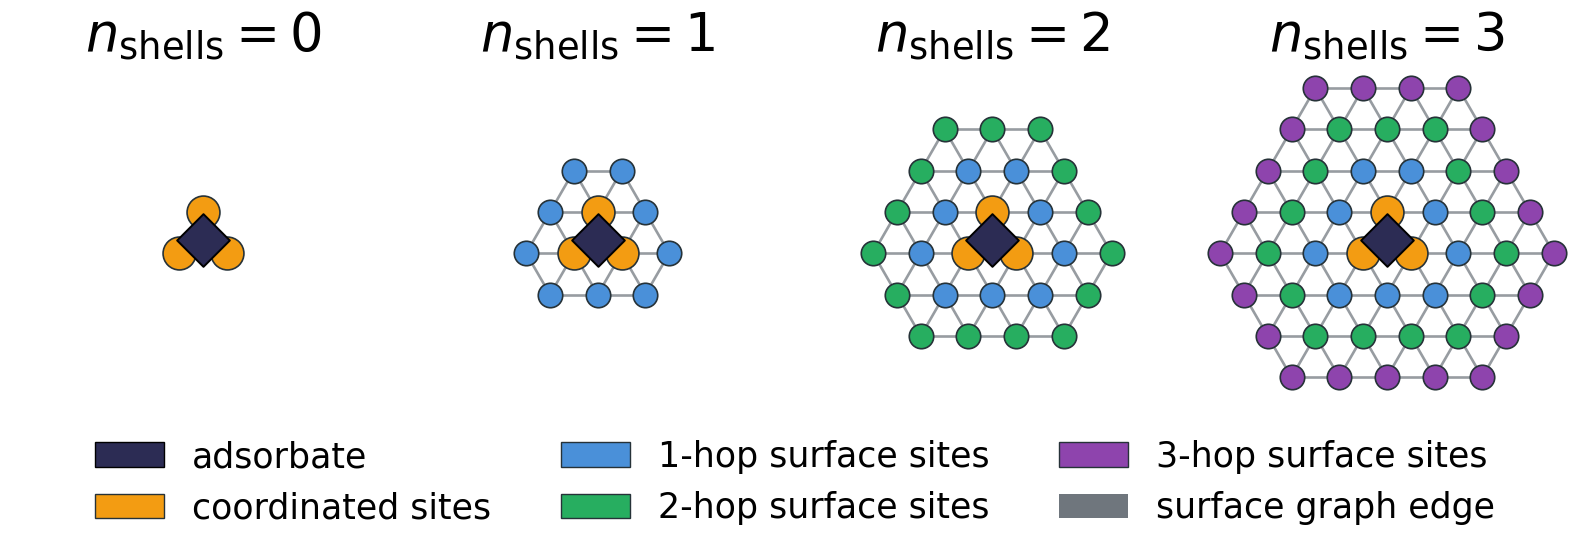

In [7]:
# -- Figure 5: Adsorbate surface-shell expansion -----------------------------
MAX_SHELL = 3
seed_clique = [(0, 0), (1, 0), (0, 1)]
neighbor_offsets = [(1, 0), (-1, 0), (0, 1), (0, -1), (1, -1), (-1, 1)]


def axial_to_xy(node):
    q, r = node
    return np.array([q + 0.5 * r, np.sqrt(3) * 0.5 * r], dtype=float)


# Build a small triangular surface graph around the coordinated clique.
surface_nodes = []
for q in range(-MAX_SHELL - 2, MAX_SHELL + 3):
    for r in range(-MAX_SHELL - 2, MAX_SHELL + 3):
        s = -q - r
        if max(abs(q), abs(r), abs(s)) <= MAX_SHELL + 1:
            surface_nodes.append((q, r))

G5 = nx.Graph()
for node in surface_nodes:
    G5.add_node(node, kind='surface', pos=axial_to_xy(node))

surface_node_set = set(surface_nodes)
for q, r in surface_nodes:
    for dq, dr in neighbor_offsets:
        nb = (q + dq, r + dr)
        if nb in surface_node_set:
            G5.add_edge((q, r), nb)

# Surface-only BFS depth from the bonded clique, matching the n_shells idea.
shell_by_node = {}
frontier = set(seed_clique)
visited = set(seed_clique)
for shell in range(MAX_SHELL + 1):
    for node in frontier:
        shell_by_node[node] = shell
    nxt = set()
    for node in frontier:
        for nb in G5.neighbors(node):
            if nb not in visited:
                nxt.add(nb)
    frontier = nxt
    visited |= nxt

shell_nodes = {
    shell: sorted(n for n, depth in shell_by_node.items() if depth == shell)
    for shell in range(MAX_SHELL + 1)
}

seed_xy = np.vstack([G5.nodes[n]['pos'] for n in seed_clique])
ads_xy = seed_xy.mean(axis=0)
max_shell_nodes = {
    node
    for node, shell in shell_by_node.items()
    if shell <= MAX_SHELL
}
max_shell_xy = np.vstack([G5.nodes[n]['pos'] for n in max_shell_nodes] + [ads_xy])
PLOT_PAD = 0.55
PLOT_XLIM = (max_shell_xy[:, 0].min() - PLOT_PAD, max_shell_xy[:, 0].max() + PLOT_PAD)
PLOT_YLIM = (max_shell_xy[:, 1].min() - PLOT_PAD, max_shell_xy[:, 1].max() + PLOT_PAD)

SHELL_COLOR = {
    0: '#F39C12',
    1: '#4A90D9',
    2: '#27AE60',
    3: '#8E44AD',
}
SHELL_LABEL = {
    0: 'coordinated sites',
    1: '1-hop surface sites',
    2: '2-hop surface sites',
    3: '3-hop surface sites',
}
ADS_COLOR = '#2C2C54'
EDGE_COLOR = '#6f767d'


def draw_shell_panel(ax, depth):
    included = {
        node
        for node, shell in shell_by_node.items()
        if shell <= depth
    }
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(r'$n_\mathrm{shells} = $' + str(depth), fontsize=38, pad=5)

    # Surface graph edges in the current cumulative ego graph.
    for a, b in G5.edges():
        if a in included and b in included:
            pa = G5.nodes[a]['pos']
            pb = G5.nodes[b]['pos']
            ax.plot(
                [pa[0], pb[0]], [pa[1], pb[1]],
                color=EDGE_COLOR, lw=1.9, alpha=0.72, zorder=1,
            )

    # Adsorbate-to-surface coordination edges stay fixed as shells expand.
    for node in seed_clique:
        p = G5.nodes[node]['pos']
        ax.plot(
            [ads_xy[0], p[0]], [ads_xy[1], p[1]],
            color='#343a40', lw=2.1, alpha=0.95, zorder=2,
        )

    for shell in range(depth + 1):
        nodes = [node for node in shell_nodes[shell] if node in included]
        xy = np.vstack([G5.nodes[node]['pos'] for node in nodes])
        ax.scatter(
            xy[:, 0], xy[:, 1],
            s=560 if shell == 0 else 310,
            c=SHELL_COLOR[shell], marker='o',
            edgecolors='#263238', linewidths=1.2,
            zorder=3 + shell,
        )

    ax.scatter(
        [ads_xy[0]], [ads_xy[1]],
        s=720, c=ADS_COLOR, marker='D',
        edgecolors='black', linewidths=1.4, zorder=10,
    )
    ax.set_xlim(PLOT_XLIM)
    ax.set_ylim(PLOT_YLIM)


fig, axes = plt.subplots(1, MAX_SHELL + 1, figsize=(16, 5.35), facecolor='white')
for depth, ax in enumerate(axes):
    draw_shell_panel(ax, depth)

legend_handles = [
    mpatches.Patch(facecolor=ADS_COLOR, edgecolor='black', label='adsorbate'),
] + [
    mpatches.Patch(
        facecolor=SHELL_COLOR[shell], edgecolor='#263238', label=SHELL_LABEL[shell],
    )
    for shell in range(MAX_SHELL + 1)
] + [
    mpatches.Patch(facecolor=EDGE_COLOR, label='surface graph edge'),
]

fig.legend(
    handles=legend_handles, loc='lower center',
    ncol=3, fontsize=25, frameon=False,
    bbox_to_anchor=(0.5, -0.04),
)

fig.tight_layout(rect=(0.0, 0.13, 1.0, 1.0), w_pad=0.6)
plt.savefig('adsorbate_shell_expansion.pdf', bbox_inches='tight')
plt.show()


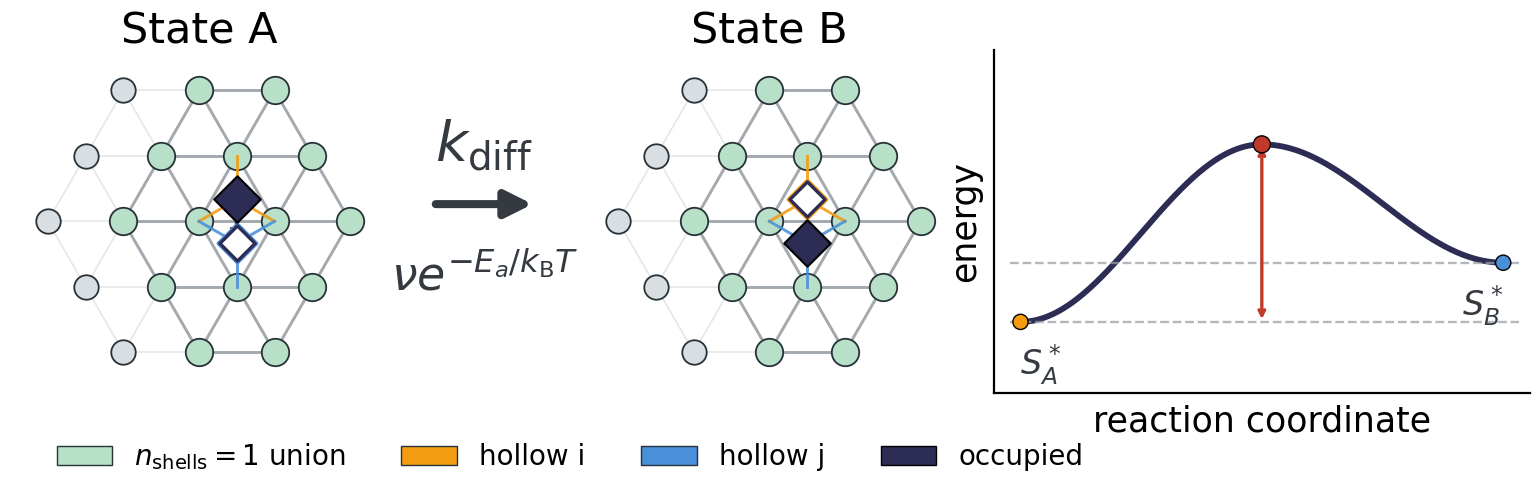

In [8]:
# -- Figure 6: Diffusion-site process ----------------------------------------
from matplotlib.gridspec import GridSpec as GS6

START_CLIQUE = [(0, 0), (1, 0), (0, 1)]
END_CLIQUE = [(0, 0), (1, 0), (1, -1)]
SURFACE_RADIUS = 2
N_SHELLS_DIFF = 1
NEIGHBOR_OFFSETS = [(1, 0), (-1, 0), (0, 1), (0, -1), (1, -1), (-1, 1)]


def axial_to_xy6(node):
    q, r = node
    return np.array([q + 0.5 * r, np.sqrt(3) * 0.5 * r], dtype=float)


def hollow_xy6(clique):
    return np.vstack([G6.nodes[n]['pos'] for n in clique]).mean(axis=0)


surface_nodes6 = []
for q in range(-SURFACE_RADIUS - 1, SURFACE_RADIUS + 2):
    for r in range(-SURFACE_RADIUS - 1, SURFACE_RADIUS + 2):
        s = -q - r
        if max(abs(q), abs(r), abs(s)) <= SURFACE_RADIUS:
            surface_nodes6.append((q, r))

G6 = nx.Graph()
for node in surface_nodes6:
    G6.add_node(node, pos=axial_to_xy6(node))

surface_set6 = set(surface_nodes6)
for q, r in surface_nodes6:
    for dq, dr in NEIGHBOR_OFFSETS:
        nb = (q + dq, r + dr)
        if nb in surface_set6:
            G6.add_edge((q, r), nb)


def surface_bfs_shell6(seed_nodes, n_shells):
    frontier = set(seed_nodes)
    visited = set(frontier)
    for _ in range(int(n_shells)):
        nxt = set()
        for node in frontier:
            for nb in G6.neighbors(node):
                if nb not in visited:
                    nxt.add(nb)
        frontier = nxt
        visited |= frontier
    return visited


# Mirrors autokmc.sites.diffusion: one surface-only BFS per endpoint clique, then union.
start_shell6 = surface_bfs_shell6(set(START_CLIQUE), N_SHELLS_DIFF)
end_shell6 = surface_bfs_shell6(set(END_CLIQUE), N_SHELLS_DIFF)
env_nodes6 = start_shell6 | end_shell6
start_hollow_xy6 = hollow_xy6(START_CLIQUE)
end_hollow_xy6 = hollow_xy6(END_CLIQUE)

all_xy6 = np.vstack(
    [G6.nodes[n]['pos'] for n in G6.nodes()] + [start_hollow_xy6, end_hollow_xy6]
)
PANEL_PAD6 = 0.5
PANEL_XLIM6 = (all_xy6[:, 0].min() - PANEL_PAD6, all_xy6[:, 0].max() + PANEL_PAD6)
PANEL_YLIM6 = (all_xy6[:, 1].min() - PANEL_PAD6, all_xy6[:, 1].max() + PANEL_PAD6)

SURF_CLR6 = '#D9DEE2'
ENV_CLR6 = '#B8E0C8'
START_CLR6 = '#F39C12'
END_CLR6 = '#4A90D9'
ADS_CLR6 = '#2C2C54'
EDGE_CLR6 = '#7C858C'


def draw_diffusion_state(ax, occupied_hollow, title):
    occupied_xy = start_hollow_xy6 if occupied_hollow == 'start' else end_hollow_xy6
    vacant_xy = end_hollow_xy6 if occupied_hollow == 'start' else start_hollow_xy6

    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=31, pad=7)

    for a, b in G6.edges():
        pa = G6.nodes[a]['pos']
        pb = G6.nodes[b]['pos']
        edge_in_env = a in env_nodes6 and b in env_nodes6
        ax.plot([pa[0], pb[0]], [pa[1], pb[1]],
                color=EDGE_CLR6, lw=2.1 if edge_in_env else 1.2,
                alpha=0.70 if edge_in_env else 0.20, zorder=1)

    for node in G6.nodes():
        p = G6.nodes[node]['pos']
        if node in env_nodes6:
            color = ENV_CLR6
            size = 390
        else:
            color = SURF_CLR6
            size = 310
        ax.scatter([p[0]], [p[1]], s=size, c=color,
                   edgecolors='#263238', linewidths=1.3, zorder=3)

    for clique, xy, color in [
        (START_CLIQUE, start_hollow_xy6, START_CLR6),
        (END_CLIQUE, end_hollow_xy6, END_CLR6),
    ]:
        for node in clique:
            p = G6.nodes[node]['pos']
            ax.plot([xy[0], p[0]], [xy[1], p[1]], color=color,
                    lw=2.1, alpha=0.88, zorder=4)

    ax.annotate('', xy=end_hollow_xy6, xytext=start_hollow_xy6,
                arrowprops=dict(arrowstyle='-|>', lw=2.8, color='#343A40',
                                mutation_scale=18, shrinkA=16, shrinkB=16),
                zorder=4)

    ax.scatter([start_hollow_xy6[0]], [start_hollow_xy6[1]], s=380, marker='D',
               c='white', edgecolors=START_CLR6, linewidths=2.6, zorder=5)
    ax.scatter([end_hollow_xy6[0]], [end_hollow_xy6[1]], s=380, marker='D',
               c='white', edgecolors=END_CLR6, linewidths=2.6, zorder=5)
    ax.scatter([vacant_xy[0]], [vacant_xy[1]], s=320, marker='D',
               c='white', edgecolors=ADS_CLR6, linewidths=2.4, zorder=5)
    ax.scatter([occupied_xy[0]], [occupied_xy[1]], s=560, marker='D',
               c=ADS_CLR6, edgecolors='black', linewidths=1.5, zorder=6)

    ax.set_xlim(PANEL_XLIM6)
    ax.set_ylim(PANEL_YLIM6)


fig = plt.figure(figsize=(16, 5.2), facecolor='white')
gs6 = GS6(1, 4, figure=fig, width_ratios=[3.1, 1.0, 3.1, 4.4],
          left=0.03, right=0.98, top=0.86, bottom=0.20, wspace=0.10)
ax_initial = fig.add_subplot(gs6[0])
ax_arrow = fig.add_subplot(gs6[1])
ax_final = fig.add_subplot(gs6[2])
ax_energy = fig.add_subplot(gs6[3])

draw_diffusion_state(ax_initial, occupied_hollow='start', title='State A')
draw_diffusion_state(ax_final, occupied_hollow='end', title='State B')

ax_arrow.axis('off')
ax_arrow.annotate('', xy=(0.92, 0.55), xytext=(0.08, 0.55),
                  xycoords='axes fraction', textcoords='axes fraction',
                  arrowprops=dict(arrowstyle='-|>', lw=5.8, color='#343A40',
                                  mutation_scale=40))
ax_arrow.text(0.50, 0.72, r'$k_{\mathrm{diff}}$', ha='center', va='center',
              fontsize=40, color='#343A40')
ax_arrow.text(0.50, 0.34, r'$\nu e^{-E_a/k_\mathrm{B}T}$',
              ha='center', va='center', fontsize=33, color='#343A40')

# Diffusion profile: final endpoint is 0.10 eV above the initial endpoint.
E_i = 0.00
E_ts = 0.30
E_f = 0.10
x_ts = 0.50

x1 = np.linspace(0.05, x_ts, 120)
t1 = (x1 - x1.min()) / (x_ts - x1.min())
e1 = E_i + (E_ts - E_i) * np.sin(t1 * np.pi / 2) ** 2
x2 = np.linspace(x_ts, 0.95, 120)
t2 = (x2 - x_ts) / (0.95 - x_ts)
e2 = E_f + (E_ts - E_f) * np.cos(t2 * np.pi / 2) ** 2
x = np.concatenate([x1, x2])
e = np.concatenate([e1, e2])

ax_energy.plot(x, e, color=ADS_CLR6, lw=4.2, solid_capstyle='round')
ax_energy.scatter([0.05, x_ts, 0.95], [E_i, E_ts, E_f], s=[120, 150, 120],
                  color=[START_CLR6, '#C0392B', END_CLR6], edgecolors='black',
                  linewidths=1.0, zorder=4)

ax_energy.hlines([E_i, E_f], xmin=0.03, xmax=0.98, colors='#9AA1A7',
                 linestyles='--', linewidths=1.7, alpha=0.75)
ax_energy.annotate('', xy=(x_ts, E_ts), xytext=(x_ts, E_i),
                   arrowprops=dict(arrowstyle='<->', lw=2.4, color='#C0392B'))
ax_energy.text(0.05, E_i - 0.035, r'$S^*_A$', fontsize=24,
               ha='left', va='top', color='#343A40')
ax_energy.text(0.95, E_f - 0.035, r'$S^*_B$', fontsize=24,
               ha='right', va='top', color='#343A40')

#ax_energy.set_title('diffusion barrier', fontsize=31, pad=7)
ax_energy.set_xlabel('reaction coordinate', fontsize=25, labelpad=8)
ax_energy.set_ylabel('energy', fontsize=25, labelpad=8)
ax_energy.set_xlim(0.00, 1.00)
ax_energy.set_ylim(E_i - 0.12, E_ts + 0.16)
ax_energy.set_xticks([])
ax_energy.set_yticks([])
ax_energy.spines['top'].set_visible(False)
ax_energy.spines['right'].set_visible(False)
ax_energy.spines['bottom'].set_linewidth(1.6)
ax_energy.spines['left'].set_linewidth(1.6)

legend_handles6 = [
    mpatches.Patch(facecolor=ENV_CLR6, edgecolor='#263238', label=r'$n_\mathrm{shells}=1$ union'),
    mpatches.Patch(facecolor=START_CLR6, edgecolor='#263238', label='hollow i'),
    mpatches.Patch(facecolor=END_CLR6, edgecolor='#263238', label='hollow j'),
    mpatches.Patch(facecolor=ADS_CLR6, edgecolor='black', label='occupied'),
]
fig.legend(handles=legend_handles6, loc='lower center', ncol=4,
           fontsize=20, frameon=False, bbox_to_anchor=(0.38, 0.00))

plt.savefig('diffusion_site_process.pdf', bbox_inches='tight')
plt.show()


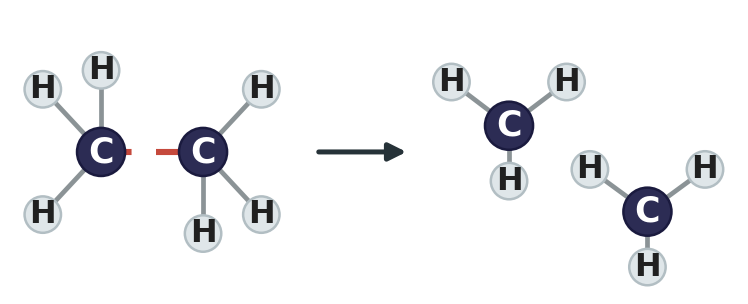

In [9]:
# -- Figure 7: Ethane dissociation graph -------------------------------------
FIG7_C = '#2C2C54'
FIG7_H = '#DFE6E9'
FIG7_EDGE = '#636E72'
FIG7_BREAK = '#C0392B'

fig, ax = plt.subplots(figsize=(9.4, 4.9), facecolor='white')
ax.set_aspect('equal')
ax.axis('off')

left_nodes = {
    'C1': {'pos': (-3.85, 0.00), 'elem': 'C'},
    'C2': {'pos': (-2.45, 0.00), 'elem': 'C'},
    'H1': {'pos': (-4.65, 0.86), 'elem': 'H'},
    'H2': {'pos': (-4.65, -0.86), 'elem': 'H'},
    'H3': {'pos': (-3.85, 1.12), 'elem': 'H'},
    'H4': {'pos': (-1.65, 0.86), 'elem': 'H'},
    'H5': {'pos': (-1.65, -0.86), 'elem': 'H'},
    'H6': {'pos': (-2.45, -1.12), 'elem': 'H'},
}
left_edges = [
    ('C1', 'H1'), ('C1', 'H2'), ('C1', 'H3'),
    ('C2', 'H4'), ('C2', 'H5'), ('C2', 'H6'),
    ('C1', 'C2'),
]

right_nodes = {
    'C3': {'pos': (1.75, 0.36), 'elem': 'C'},
    'H7': {'pos': (0.96, 0.96), 'elem': 'H'},
    'H8': {'pos': (2.54, 0.96), 'elem': 'H'},
    'H9': {'pos': (1.75, -0.40), 'elem': 'H'},
    'C4': {'pos': (3.65, -0.82), 'elem': 'C'},
    'H10': {'pos': (2.86, -0.24), 'elem': 'H'},
    'H11': {'pos': (4.44, -0.24), 'elem': 'H'},
    'H12': {'pos': (3.65, -1.58), 'elem': 'H'},
}
right_edges = [
    ('C3', 'H7'), ('C3', 'H8'), ('C3', 'H9'),
    ('C4', 'H10'), ('C4', 'H11'), ('C4', 'H12'),
]

all_nodes = {**left_nodes, **right_nodes}
for a, b in left_edges + right_edges:
    pa = all_nodes[a]['pos']
    pb = all_nodes[b]['pos']
    is_breaking_bond = {a, b} == {'C1', 'C2'}
    ax.plot(
        [pa[0], pb[0]], [pa[1], pb[1]],
        color=FIG7_BREAK if is_breaking_bond else FIG7_EDGE,
        lw=4.4 if is_breaking_bond else 3.4,
        alpha=0.92 if is_breaking_bond else 0.74,
        linestyle=(0, (5, 4)) if is_breaking_bond else '-',
        solid_capstyle='round', zorder=1,
    )

for name, info in all_nodes.items():
    x, y = info['pos']
    elem = info['elem']
    is_carbon = elem == 'C'
    radius = 0.33 if is_carbon else 0.25
    ax.add_patch(mpatches.Circle(
        (x, y), radius,
        facecolor=FIG7_C if is_carbon else FIG7_H,
        edgecolor='#1A1A3E' if is_carbon else '#B2BEC3',
        linewidth=1.8, zorder=3,
    ))
    ax.text(
        x, y, elem,
        ha='center', va='center',
        fontsize=25 if is_carbon else 23,
        fontweight='bold',
        color='white' if is_carbon else '#202020',
        zorder=4,
    )

ax.annotate(
    '', xy=(0.38, 0.0), xytext=(-0.90, 0.0),
    arrowprops=dict(arrowstyle='-|>', lw=3.6, color='#263238', mutation_scale=26),
    zorder=2,
)
#ax.text(-0.26, 1.32, 'Dissociation', ha='center', va='bottom',
#        fontsize=31, fontweight='bold', color='#263238')

ax.set_xlim(-5.10, 4.90)
ax.set_ylim(-1.95, 1.95)
plt.savefig('reactant_bond_template_graph.pdf', bbox_inches='tight')
plt.show()


/var/folders/1q/32s9jt015s98x724gblpp5340020jy/T/ipykernel_44294/2767532292.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.20)


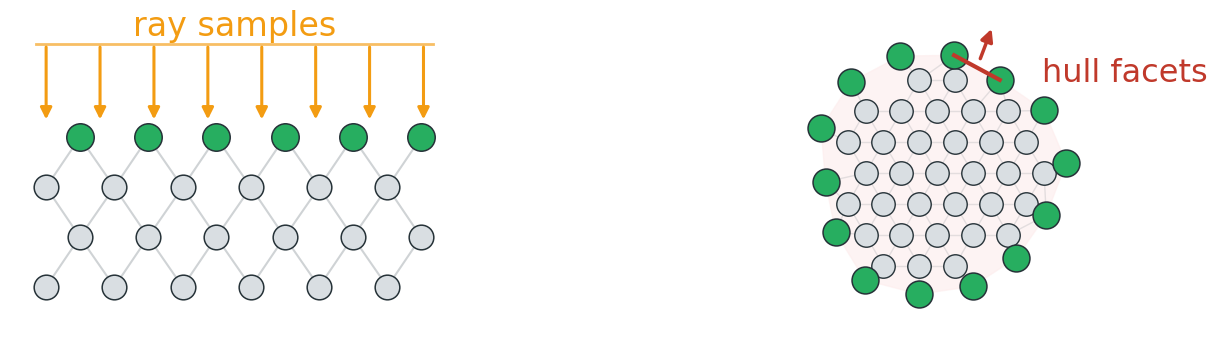

In [10]:
# -- Figure 8: Surface classification methods ---------------------------------
from matplotlib.gridspec import GridSpec as GS8
from matplotlib.path import Path as MplPath

fig = plt.figure(figsize=(13.8, 4.9), facecolor='white')
gs8 = GS8(1, 2, figure=fig, left=0.04, right=0.98, top=0.82, bottom=0.14,
          wspace=0.18)
ax_ray = fig.add_subplot(gs8[0])
ax_hull = fig.add_subplot(gs8[1])

BULK_CLR8 = '#D9DEE2'
SURF_CLR8 = '#27AE60'
EDGE_CLR8 = '#7C858C'
RAY_CLR8 = '#F39C12'
HULL_CLR8 = '#C0392B'
TEXT_CLR8 = '#263238'
FILL_CLR8 = '#FDECEC'

# Left panel: periodic slab ray-casting.
ax_ray.set_aspect('equal')
ax_ray.axis('off')
rows = []
for layer, y in enumerate([0.0, 0.62, 1.24, 1.86]):
    xs = np.arange(6, dtype=float) * 0.85 + (0.42 if layer % 2 else 0.0)
    for x in xs:
        rows.append((x, y, layer))

for i, (x1, y1, l1) in enumerate(rows):
    for x2, y2, l2 in rows[i + 1:]:
        d = np.hypot(x2 - x1, y2 - y1)
        if d < 0.78:
            ax_ray.plot([x1, x2], [y1, y2], color=EDGE_CLR8,
                        lw=1.5, alpha=0.36, zorder=1)

for x, y, layer in rows:
    is_surface = layer == 3
    ax_ray.scatter([x], [y], s=390 if is_surface else 315,
                   c=SURF_CLR8 if is_surface else BULK_CLR8,
                   edgecolors='#263238', linewidths=1.1, zorder=4)

# Ray samples are placed in xy and assigned to the highest atom underneath.
ray_xs = np.linspace(0.0, 4.7, 8)
for x in ray_xs:
    ax_ray.annotate('', xy=(x, 2.05), xytext=(x, 3.02),
                    arrowprops=dict(arrowstyle='-|>', lw=2.2,
                                    color=RAY_CLR8, mutation_scale=17),
                    zorder=5)
ax_ray.plot([ray_xs.min() - 0.12, ray_xs.max() + 0.12], [3.02, 3.02],
            color=RAY_CLR8, lw=2.0, alpha=0.65)
ax_ray.text(2.35, 3.25, 'ray samples', ha='center', va='center',
            fontsize=24, color=RAY_CLR8)
#ax_ray.text(2.35, -0.38, 'atoms receiving enough\nexposed ray hits are surface',
#            ha='center', va='top', fontsize=21, color=TEXT_CLR8, linespacing=0.92)
ax_ray.set_xlim(-0.45, 5.15)
ax_ray.set_ylim(-0.70, 3.45)
#ax_ray.set_title('ray casting for slabs', fontsize=31, pad=4)

# Right panel: nanoparticle convex-hull classification.
ax_hull.set_aspect('equal')
ax_hull.axis('off')

angles = np.linspace(0.0, 2.0 * np.pi, 14, endpoint=False) + 0.08
radii = 1.42 * (1.0 + 0.055 * np.cos(3.0 * angles - 0.45)
                + 0.030 * np.sin(5.0 * angles + 0.35))
hull = np.column_stack([radii * np.cos(angles), radii * np.sin(angles)])
closed = np.vstack([hull, hull[0]])
hull_path = MplPath(hull)

# Distance to the faceted hull; used to mark atoms close to the hull as surface.
def point_to_segment_distance(point, a, b):
    ab = b - a
    t = np.clip(np.dot(point - a, ab) / np.dot(ab, ab), 0.0, 1.0)
    proj = a + t * ab
    return float(np.linalg.norm(point - proj))


def distance_to_hull(point):
    return min(
        point_to_segment_distance(point, hull[i], hull[(i + 1) % len(hull)])
        for i in range(len(hull))
    )

# Build a small triangular-lattice particle interior.
spacing = 0.42
candidate_pts = []
for row in range(-5, 6):
    y = row * spacing * np.sqrt(3.0) / 2.0
    x_shift = 0.5 * spacing if row % 2 else 0.0
    for col in range(-6, 7):
        x = col * spacing + x_shift
        p = np.array([x, y])
        if hull_path.contains_point(p):
            d_edge = distance_to_hull(p)
            # Keep the drawing open enough for labels and atom identity.
            if d_edge > 0.20:
                candidate_pts.append((p, d_edge))

near_surface = []
interior = [p for p, d in candidate_pts]
outer = [p for p in hull]

# Faint atom-neighbour links.
point_groups = [outer, near_surface, interior]
all_pts = np.vstack([np.vstack(group) for group in point_groups if len(group)])
for i in range(len(all_pts)):
    for j in range(i + 1, len(all_pts)):
        if np.linalg.norm(all_pts[i] - all_pts[j]) < 0.52:
            ax_hull.plot([all_pts[i, 0], all_pts[j, 0]], [all_pts[i, 1], all_pts[j, 1]],
                         color=EDGE_CLR8, lw=1.0, alpha=0.20, zorder=1)

ax_hull.fill(closed[:, 0], closed[:, 1], color=FILL_CLR8, alpha=0.58, zorder=0)
# The convex hull is used for classification, but the atom boundary is left
# unoutlined so the particle remains visually clean.

if interior:
    arr = np.vstack(interior)
    ax_hull.scatter(arr[:, 0], arr[:, 1], s=285, c=BULK_CLR8,
                    edgecolors='#263238', linewidths=1.0, zorder=4)
if near_surface:
    arr = np.vstack(near_surface)
    ax_hull.scatter(arr[:, 0], arr[:, 1], s=330, c=SURF_CLR8,
                    edgecolors='#263238', linewidths=1.0, zorder=5)
arr = np.vstack(outer)
ax_hull.scatter(arr[:, 0], arr[:, 1], s=375, c=SURF_CLR8,
                edgecolors='#263238', linewidths=1.1, zorder=6)

# Facet-normal cue.
facet_i = 2
facet_a = hull[facet_i]
facet_b = hull[(facet_i + 1) % len(hull)]
mid = 0.5 * (facet_a + facet_b)
normal = mid / np.linalg.norm(mid)
ax_hull.plot([facet_a[0], facet_b[0]], [facet_a[1], facet_b[1]],
             color=HULL_CLR8, lw=3.0, zorder=7)
ax_hull.annotate('', xy=mid + 0.52 * normal, xytext=mid + 0.08 * normal,
                 arrowprops=dict(arrowstyle='-|>', lw=2.5,
                                 color=HULL_CLR8, mutation_scale=18), zorder=8)
ax_hull.text(1.24, 1.18, 'hull facets', ha='left', va='center',
             fontsize=23, color=HULL_CLR8)
#ax_hull.text(0.0, -1.78, 'atoms on the hull boundary\nare tagged as surface',
#             ha='center', va='top', fontsize=21, color=TEXT_CLR8, linespacing=0.92)
ax_hull.set_xlim(-2.05, 2.05)
ax_hull.set_ylim(-2.00, 1.92)
#ax_hull.set_title('convex hull for particles', fontsize=31, pad=4)

fig.tight_layout(pad=0.20)
plt.savefig('surface_classification_methods.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# -- Figure 9: Lateral interaction within one surface shell -------------------
fig, ax = plt.subplots(figsize=(7.4, 5.2), facecolor='white')

SURF_CLR9 = '#d9d9d9'
SHELL_CLR9 = '#ccebc5'
TARGET_CLR9 = '#5b6fb0'
OCC_CLR9 = '#ff9f1c'
SHELL_EDGE9 = '#2ca25f'
EDGE_CLR9 = '#9aa3a7'
TEXT_CLR9 = '#202020'

NEIGHBOR_OFFSETS9 = [(1, 0), (-1, 0), (0, 1), (0, -1), (1, -1), (-1, 1)]

def axial_to_xy9(node):
    q, r = node
    return np.array([q + 0.5 * r, np.sqrt(3) * r / 2.0], dtype=float)

nodes9 = [(q, r) for q in range(-2, 3) for r in range(-2, 3)]
pos9 = {node: axial_to_xy9(node) for node in nodes9}
G9 = nx.Graph()
G9.add_nodes_from(nodes9)
for node in nodes9:
    q, r = node
    for dq, dr in NEIGHBOR_OFFSETS9:
        nb = (q + dq, r + dr)
        if nb in pos9:
            G9.add_edge(node, nb)

target_clique9 = [(0, 0), (1, 0), (0, 1)]
occupied_clique9 = [(1, 0), (1, 1), (0, 1)]
shell_nodes9 = set(target_clique9)
for node in target_clique9:
    shell_nodes9.update(G9.neighbors(node))

target_xy9 = np.vstack([pos9[n] for n in target_clique9]).mean(axis=0)
occupied_xy9 = np.vstack([pos9[n] for n in occupied_clique9]).mean(axis=0)
all_xy9 = np.vstack([pos9[n] for n in nodes9])
shell_xy9 = np.vstack([pos9[n] for n in shell_nodes9])

# Faint surface graph.
for u, v in G9.edges():
    pu, pv = pos9[u], pos9[v]
    ax.plot([pu[0], pv[0]], [pu[1], pv[1]], color=EDGE_CLR9,
            lw=0.75, alpha=0.38, zorder=1)

ax.scatter(all_xy9[:, 0], all_xy9[:, 1], s=90, facecolor=SURF_CLR9,
           edgecolor='#687176', linewidth=0.8, zorder=2)
ax.scatter(shell_xy9[:, 0], shell_xy9[:, 1], s=105, facecolor=SHELL_CLR9,
           edgecolor=SHELL_EDGE9, linewidth=1.2, zorder=3)

def draw_clique9(clique, color, lw=3.1):
    pts = np.vstack([pos9[n] for n in clique])
    closed = np.vstack([pts, pts[0]])
    ax.plot(closed[:, 0], closed[:, 1], color=color, lw=lw,
            alpha=0.82, zorder=5)

draw_clique9(target_clique9, TARGET_CLR9)
draw_clique9(occupied_clique9, OCC_CLR9)

center9 = shell_xy9.mean(axis=0)
radius9 = np.max(np.linalg.norm(shell_xy9 - center9, axis=1)) + 0.18
ax.add_patch(mpatches.Circle(center9, radius9, fill=False, linestyle='--',
                             linewidth=2.6, edgecolor=SHELL_EDGE9,
                             zorder=4))

ax.scatter([target_xy9[0]], [target_xy9[1]], s=360, marker='D',
           facecolor=TARGET_CLR9, edgecolor='black', linewidth=1.2, zorder=7)
ax.scatter([occupied_xy9[0]], [occupied_xy9[1]], s=360, marker='D',
           facecolor=OCC_CLR9, edgecolor='black', linewidth=1.2, zorder=8)

ax.text(center9[0] - 1.45, center9[1] - 1.56, r'$n_{\mathrm{shells}} = 1$',
        color=SHELL_EDGE9, fontsize=26, fontweight='bold', ha='left', va='center')
ax.annotate('occupied neighbor', xy=occupied_xy9, xytext=(occupied_xy9[0] + 0.08, occupied_xy9[1] + 0.90),
            arrowprops=dict(arrowstyle='->', color=OCC_CLR9, lw=1.8),
            color=OCC_CLR9, fontsize=19, ha='left', va='center')
ax.annotate('target site', xy=target_xy9, xytext=(target_xy9[0] - 1.55, target_xy9[1] + 0.30),
            arrowprops=dict(arrowstyle='->', color=TARGET_CLR9, lw=1.8),
            color=TARGET_CLR9, fontsize=19, ha='right', va='center')

ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xlim(center9[0] - 2.35, center9[0] + 2.72)
ax.set_ylim(center9[1] - 2.12, center9[1] + 2.02)

plt.savefig('lateral_interactions.pdf', bbox_inches='tight')
plt.show()
